# Data Exploration

This notebook explores the raw and processed URL datasets used in the project.

The analysis focuses on:

- dataset size and class distribution;
- consistency between the training and test splits;
- URL length and basic structural characteristics;
- potential data-quality issues before model training.

URLs contained in the dataset should be treated as untrusted data.

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv(Path("../data/raw/phishing_site_urls_github.csv"))
print(df.head())
print(df["Label"].value_counts())

                                                 URL Label
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3  mail.printakid.com/www.online.americanexpress....   bad
4  thewhiskeydregs.com/wp-content/themes/widescre...   bad
Label
good    392924
bad     156422
Name: count, dtype: int64


In [16]:
BASE_DIR = Path("..").resolve()
train_path = BASE_DIR / "data" / "processed" / "urls_train.csv"
test_path  = BASE_DIR / "data" / "processed" / "urls_test.csv"

In [17]:
BASE_DIR = Path("..").resolve()
train_path = BASE_DIR / "data" / "processed" / "urls_train.csv"
test_path  = BASE_DIR / "data" / "processed" / "urls_test.csv"

In [18]:
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

In [19]:
print("Train:", train_df.shape)
print("Test: ", test_df.shape)
print("Train label distribution:")
print(train_df["label"].value_counts(normalize=True))
print("Test label distribution:")
print(test_df["label"].value_counts(normalize=True))

train_df.head()

Train: (439476, 3)
Test:  (110170, 3)
Train label distribution:
label
0    0.715259
1    0.284741
Name: proportion, dtype: float64
Test label distribution:
label
0    0.713307
1    0.286693
Name: proportion, dtype: float64


,url,label,source
0,richiefaulknercars.ie/,0,github
1,hongtongsoft.com.cn/images/index.htm?ref=us.ba...,1,github
2,archive.chicagobreakingsports.com/2009/11/rush...,0,github
3,worldlanguage.com/Languages/Belarusian.htm,0,github
4,asiandream.ru/files/test/cameo.php?login,1,github


In [20]:
train_df["url_len"] = train_df["url"].str.len()
test_df["url_len"] = test_df["url"].str.len()

In [21]:
print(train_df["url_len"].describe())
print(test_df["url_len"].describe())

count    439476.000000
mean         50.722931
std          44.433704
min           1.000000
25%          29.000000
50%          40.000000
75%          59.000000
max        2307.000000
Name: url_len, dtype: float64
count    110170.000000
mean         50.819179
std          44.314274
min           1.000000
25%          29.000000
50%          40.000000
75%          59.000000
max        1492.000000
Name: url_len, dtype: float64


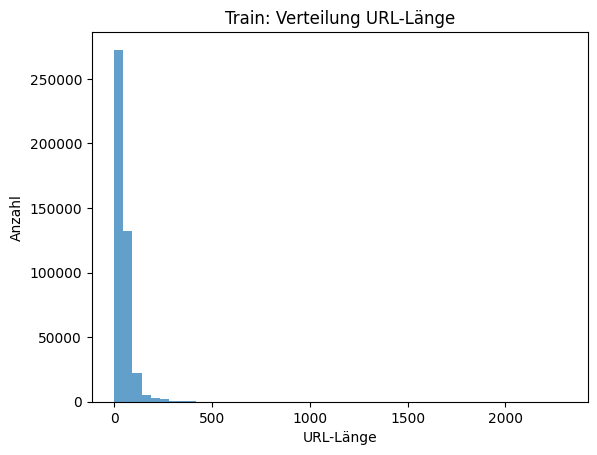

In [22]:
plt.hist(train_df["url_len"], bins=50, alpha=0.7)
plt.xlabel("URL-Länge")
plt.ylabel("Anzahl")
plt.title("Train: Verteilung URL-Länge")
plt.show()

In [23]:
from urllib.parse import urlsplit

In [24]:
def get_domain(u: str) -> str:
    try:
        s = urlsplit(u if u.startswith("http") else "http://" + u)
        return s.netloc.lower()
    except Exception:
        return ""

In [25]:
train_df["domain"] = train_df["url"].astype(str).apply(get_domain)

print(train_df["domain"].value_counts().head(20))

domain
en.wikipedia.org                                 10561
youtube.com                                       6954
facebook.com                                      6274
amazon.com                                        3716
imdb.com                                          2749
linkedin.com                                      2691
tools.ietf.org                                    2550
myspace.com                                       2341
mylife.com                                        2280
manta.com                                         1700
wn.com                                            1499
absoluteastronomy.com                             1499
answers.com                                       1323
pipl.com                                          1310
twitter.com                                       1172
'9d345009-a-62cb3a1a-s-sites.googlegroups.com     1114
www.angelfire.com                                 1036
spoke.com                                          888
peo

In [26]:
BASE_DIR = Path("..").resolve()
train_feat_path = BASE_DIR / "data" / "processed" / "urls_train_features.csv"

In [27]:
feat_df = pd.read_csv(train_feat_path)
feat_df.head()
feat_df.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
label,0.284741,0.451292,0.0,1.0
url_len,50.722931,44.433704,1.0,2307.0
num_digits,4.764130,11.528947,0.0,545.0
num_letters,39.017291,31.296361,0.0,2141.0
num_slash,2.445278,1.596792,0.0,35.0
num_dot,2.060217,1.511411,0.0,37.0
num_dash,1.126046,2.419465,0.0,42.0
num_at,0.003886,0.067719,0.0,10.0
num_qmark,0.160860,0.474760,0.0,166.0
num_equal,0.278029,0.954742,0.0,34.0
